# (노트) matplotlib + seaborn, qqplot
- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [시각화]

### import

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy import stats
import seaborn as sns
from plotnine import *

### 예제1: 왼쪽에 matplotlib, 오른쪽에 seaborn

`-` 키+뭄무게 예제를 조금 바꿔보자.

In [3]:
x=[44,48,49,58,62,68,69,70,76,79] ## 몸무게 
y=[159,160,162,165,167,162,165,175,165,172] ## 키
g= 'f','f','f','f','m','f','m','m','m','m'

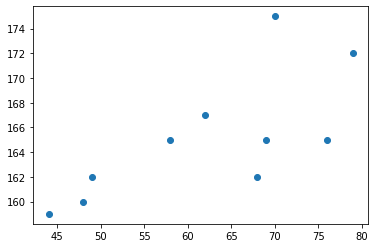

In [4]:
plt.plot(x,y,'o')

<AxesSubplot:>

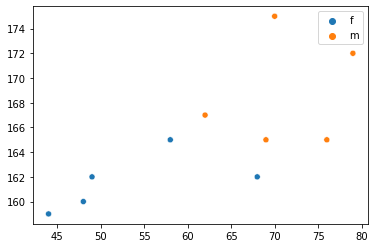

In [5]:
sns.scatterplot(x=x,y=y,hue=g)

`-` 왼쪽에는 matplotlib, 오른쪽에는 seaborn을 배치해보자. 

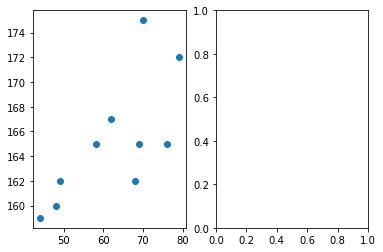

In [6]:
fig, (ax1,ax2) = plt.subplots(1,2)
ax1.plot(x,y,'o')

In [7]:
sns.scatterplot(x=x,y=y,hue=g,ax=ax2)

<AxesSubplot:>

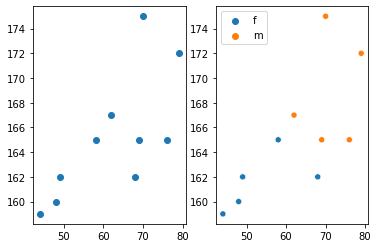

In [8]:
fig

In [9]:
fig.set_figwidth(8)

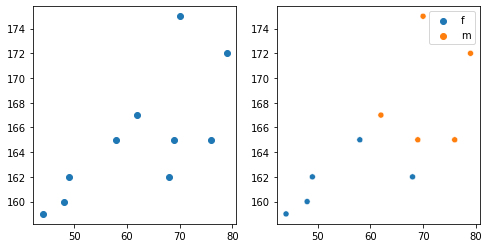

In [10]:
fig

In [11]:
ax1.set_title('matplotlib')
ax2.set_title('seaborn')

Text(0.5, 1.0, 'seaborn')

### 예제2 (정규분포와 t분포): 왼쪽에 matplotlib으로 박스플랏, 오른쪽에 seaborn으로 히스토그램 

`-` 전북고예제: 통계학에서 제시하는 통계량(평균)이 의미가 있으려면 적절한 분포가 가정되어야 한다. 

`-` 분포의 가정되었는지 어떻게 알지? 히스토그램? 

`-` 아래와 같은 자료가 있다고 하자. 

In [12]:
np.random.seed(43052)
x=np.random.normal(size=1000,loc=2,scale=1.5)

`-` 이 자료가 정규분포를 따르는지 어떻게 체크할 수 있을까? 

(array([0.01104167, 0.02650001, 0.10931252, 0.19433338, 0.25616672,
        0.24512505, 0.18218754, 0.05852085, 0.01766667, 0.0033125 ]),
 array([-2.44398446, -1.53832428, -0.6326641 ,  0.27299608,  1.17865626,
         2.08431645,  2.98997663,  3.89563681,  4.80129699,  5.70695718,
         6.61261736]),
 <BarContainer object of 10 artists>)

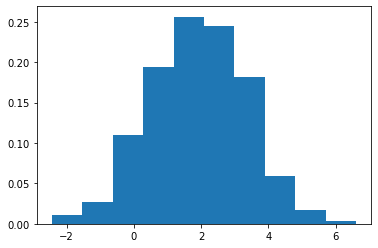

In [13]:
plt.hist(x,density=True)

`-` 종모양이다..? 

`-` 밀도추정곡선이 있었으면 좋겠다. (KDE로 추정한..) 
- 그런데 KDE는 통계적 기법이 포함된 시각화이므로 기본적인 패키지인 matplotlib에서는 지원불가능 
- seaborn에는 구현되어있음 

`-` seaborn으로 그려보자. 

<AxesSubplot:ylabel='Count'>

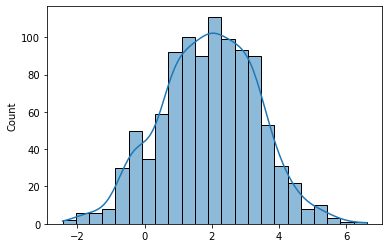

In [14]:
sns.histplot(x,kde=True)

`-` 그렇다면 아래는 어떤가? 

In [15]:
np.random.seed(43052)
y = stats.t.rvs(10, size=1000)

(array([  1.,   2.,  10.,  47., 193., 335., 292.,  94.,  22.,   4.]),
 array([-5.45810644, -4.50573513, -3.55336382, -2.60099251, -1.6486212 ,
        -0.69624989,  0.25612142,  1.20849274,  2.16086405,  3.11323536,
         4.06560667]),
 <BarContainer object of 10 artists>)

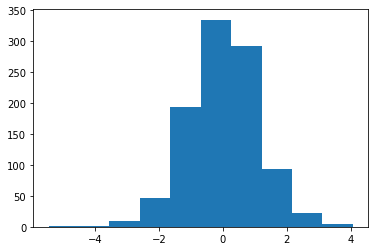

In [16]:
plt.hist(y)

`-` 종 모양이다..? 

<AxesSubplot:ylabel='Count'>

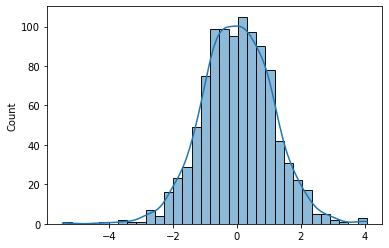

In [17]:
sns.histplot(y,kde=True)

`-` 비교

<AxesSubplot:ylabel='Count'>

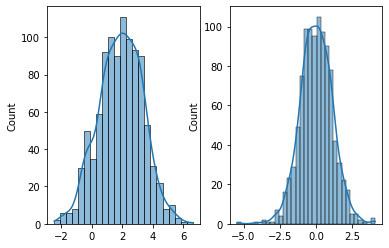

In [18]:
fig, (ax1,ax2)=plt.subplots(1,2)
sns.histplot(x,kde=True,ax=ax1)
sns.histplot(y,kde=True,ax=ax2)

<AxesSubplot:ylabel='Count'>

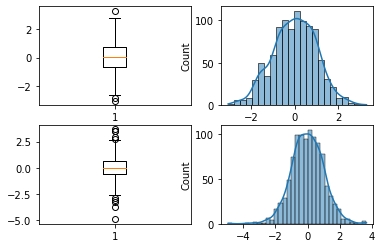

In [19]:
xx= (x-np.mean(x))/np.std(x,ddof=1)
yy= (y-np.mean(y))/np.std(y,ddof=1)

fig, ((ax1,ax2),(ax3,ax4)) =plt.subplots(2,2)
ax1.boxplot(xx)
sns.histplot(xx,kde=True,ax=ax2)
ax3.boxplot(yy)
sns.histplot(yy,kde=True,ax=ax4)

In [20]:
ax2.set_xlim(-5,5)
ax4.set_xlim(-5,5)
fig.tight_layout()

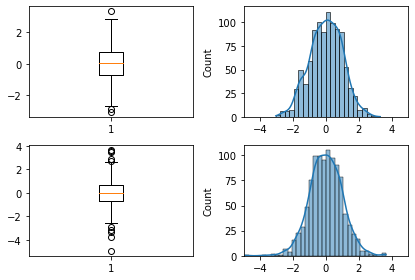

In [21]:
fig

`-` 좀 이상하다.. 
- 일단 이 분포는 정규분포가 아니었음. $\to$ "히스토그램을 그려보니 모양이 종모양이므로 정규분포라고 볼수있다" 라고 결론내리면 오류임 
- 자세히보니까 모양이 약간 다른것 같기도하고... (꼬리가 두꺼움) 

`-` 예제2에 대한 디스커션: 종모양의 히스토그램으로 정규분포인지 판단하는것은 무리가 있어보인다. $\to$ 좀 더 체계적인 방법이 필요함. 

### 예제3 (qqplot): 예제2와 같은 히스토그램 말고 더 좋은 시각화 방법은 없을까? 

In [22]:
np.random.seed(43052)
x=np.random.normal(size=1000,loc=2,scale=1.5)
y=stats.t.rvs(10, size=1000)/np.sqrt(10/8)*1.5  + 2 

`-` 우리가 관측한 $x_1,\dots, x_{1000}$이 $N(2,1.5^2)$에서 나온 샘플인지 궁금하다. 

`-` 아래와 같이 비교하면 좋을것 같다. 

(1) 관측한 값을 순서대로 나열하여 $x_{(1)},\dots,x_{(1000)}$을 만든다. 

(2) 파이썬이나 R을 통해서 $N(2,1.5^2)$에서 1000개의 정규분포를 생성한다. 그리고 순서대로 나열하여 $\tilde{x}_{(1)},\dots,\tilde{x}_{(1000)}$을 만든다. 

(3) $x_{(1)}\approx \tilde{x}_{(1)}, \dots , x_{(1000)}\approx \tilde{x}_{(1000)}$이면 정규분포일것 

`-` 그런데 $\tilde{x}_{(1)},\dots, \tilde{x}_{(1000)}$은 시뮬레이션 할때마다 다른값이 나올테니까 불안정한 느낌이다. $\to$ 이론적인 값을 계산하자. 

In [23]:
x.sort()
xx= (x-np.mean(x)) / np.std(x,ddof=1)

In [24]:
xx[:2]

array([-3.05569305, -2.84275629])

- `xx[0]`은 대략 주어진 자료의 $\frac{1}{1000}$분위수, `xx[1]`은 대략 주어진 자료의 $\frac{2}{1000}$분위수라고 볼 수 있다. 

In [25]:
print(stats.norm.ppf(0.001))
print(stats.norm.ppf(0.002))

-3.090232306167813
-2.878161739095483


`-` 분위수

In [26]:
m=[i/1000 for i in np.arange(1000)+1]

In [27]:
q=[]
for i in range(len(m)):
    q=q+[stats.norm.ppf(m[i])]
q[:2]

[-3.090232306167813, -2.878161739095483]

`-` $xx \approx q$ 임을 확인하기 위해서 $(q,q)$ 그래프와 $(q,xx)$ 그래프를 겹쳐서 그려보자. 

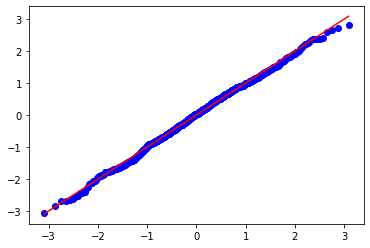

In [28]:
plt.plot(q,xx,'ob')
plt.plot(q,q,'-r')

- 해석: 점들이 붉은선근처에 모여있을수록 정규분포에 가깝다.

`-` 아래와 같이 쉽게 그릴수도 있다. (조금 다르게 그려진다. 보정치..)

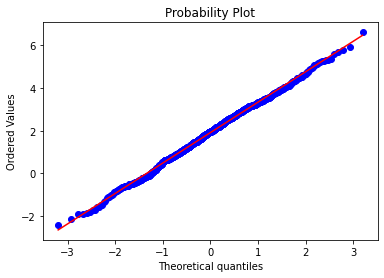

In [29]:
from scipy import stats
_ = stats.probplot(x,plot=plt)

- 자세히보면 조금 다르게 그려지긴 하는데 이는 $m=(\frac{1}{1000},\dots,\frac{999}{1000},\frac{1000}{1000})$와 같이 계산하지 않고 약간 보정한값을 계산하기 때문임 
- stats.probplot? 을 통하여 확인한 결과 아래와 같은 코드로 구현됨
```python
### 보정하는방법1 
n=len(xx)
m=[((i+1)-0.3175)/(n+0.365) for i in range(n)]
m[-n]=0.5**(1/n)
m[0]=1-m[-n]
```
- 프로그램에 따라서 아래와 같이 보정하는 경우도 있음
```python
### 보정하는방법2
m=[(i-3/8)/(n+1/4) for i in np.arange(100)+1]
```
- 또 자세히보면 stats.probplot은 y축에 표준화전의 x값이 있음을 알 수 있음. 

`-` 정규분포와 t분포의 qqplot을 그려서 비교해보자 

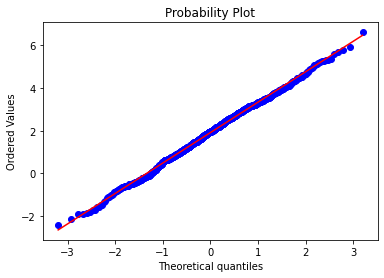

In [30]:
_ = stats.probplot(x,plot=plt) ## 정규분포 

- 푸른점들이 붉은선을 따라서 크게 벗어남없이 분포하는듯 보인다. 

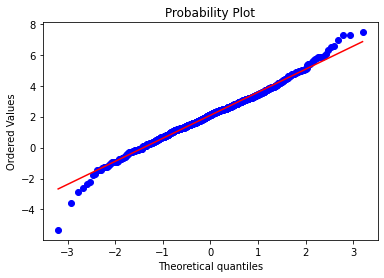

In [31]:
_ = stats.probplot(y,plot=plt) ## t분포 

- 푸른점들이 대체로 붉은선위에 놓여있는듯하지만, 양끝단에서는 그렇지 않다. (중앙부분은 정규분포와 비슷하지만 꼬리부분은 정규분포와 확실히 다르다)
- 왼쪽꼬리: 이론적인 값보다 더 작은값 (음의 절대값이 더 큰..) 
- 오른쪽꼬리: 이론적인 값보다 더 큰값 (양의 절대값이 더 큰..) 
- 해석: 이 분포는 정규분포보다 두꺼운 꼬리를 가진다. 

`-` 서브플랏팅: 두 분포를 양옆에 나란히 비교하고 싶다. 

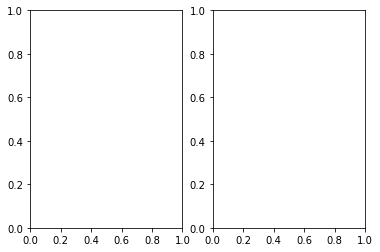

In [32]:
fig,(ax1,ax2) =plt.subplots(1,2)

In [33]:
_ = stats.probplot(x,plot=ax1)
_ = stats.probplot(y,plot=ax2)

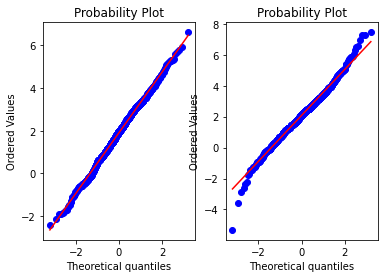

In [34]:
fig

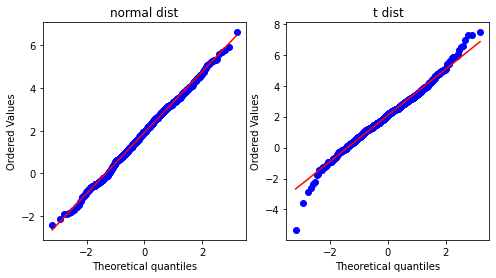

In [35]:
fig.set_figwidth(8)
ax1.set_title("normal dist")
ax2.set_title("t dist")
fig

### 예제4 (boxplot, histogram, qqplot) 

`-` 박스플랏, 히스토그램, qqplot을 그려보자. 

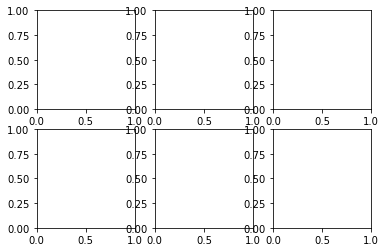

In [36]:
fig, ax =plt.subplots(2,3)

In [37]:
(ax1,ax2,ax3),(ax4,ax5,ax6) = ax 

In [38]:
sns.boxplot(x,ax=ax1)
sns.histplot(x,kde=True,ax=ax2)
_ = stats.probplot(x,plot=ax3)
sns.boxplot(y,ax=ax4)
sns.histplot(y,kde=True,ax=ax5)
_ = stats.probplot(y,plot=ax6)

/home/cgb2/anaconda3/envs/py38r40/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
/home/cgb2/anaconda3/envs/py38r40/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


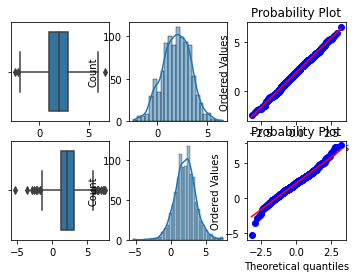

In [39]:
fig

In [40]:
fig.set_figheight(8)
fig.set_figwidth(10)
fig.tight_layout()

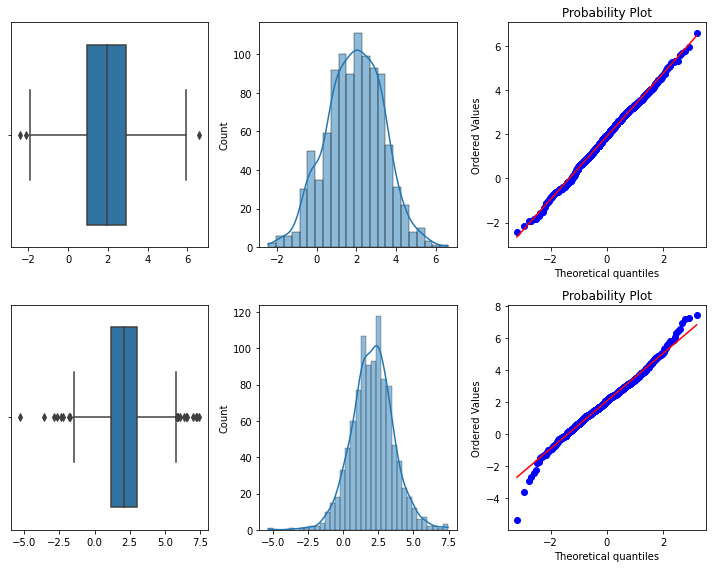

In [41]:
fig

### Appendix: 분위수를 구하는 다양한 방법

In [43]:
m=[i/1000 for i in np.arange(1000)+1]

`-` 방법1

In [46]:
q=[]
for i in range(len(m)):
    q=q+[stats.norm.ppf(m[i])]
q[:5]

[-3.090232306167813,
 -2.878161739095483,
 -2.7477813854449926,
 -2.6520698079021954,
 -2.575829303548901]

`-` 방법2 

In [47]:
q=[stats.norm.ppf(m[i]) for i in range(len(q))]
q[:5]

[-3.090232306167813,
 -2.878161739095483,
 -2.7477813854449926,
 -2.6520698079021954,
 -2.575829303548901]

`-` 방법3

In [48]:
q=list(map(stats.norm.ppf,m))
q[:5]

[-3.090232306167813,
 -2.878161739095483,
 -2.7477813854449926,
 -2.6520698079021954,
 -2.575829303548901]

### Appendix: lambda, map

#### lambda

`-` 예제1: 사용방법

In [51]:
f= lambda x,y,z: x+y+z ## 람다 입력:출력 

In [52]:
f(2,3,4)

9

`-` 예제2: 디폴트입력가능

In [54]:
x= (lambda a='fee', b='fie', c='foe': a+b+c) 

In [55]:
x('wee')

'weefiefoe'

`-` 예제3: 람다들의 리스트 가능

In [56]:
L=[lambda x: x**2, 
   lambda x: x**3, 
   lambda x: x**4]

In [57]:
for f in L: 
    print(f(2))

4
8
16


In [58]:
L[0](2)

4

`-` 예제4: 람다들의 딕셔너리가능

In [66]:
dct={'func1': (lambda x: x+1), 
     'func2': (lambda x: x+22), 
     'func3': (lambda x: x+333)} 

In [68]:
dct['func1'](1),dct['func2'](1),dct['func3'](1) # dict[key]

(2, 23, 334)

`-` 예제5: 조건부출력

(예비학습) 문자열의 대소비교

In [69]:
'a'<'b'

True

In [70]:
'c'<'b'

False

(예제시작) 

In [71]:
lower = lambda x,y : x if x<y else y 

In [72]:
lower('a','b')

'a'

In [73]:
lower('c','b')

'b'

`-` 예제6: lambda expression 자체를 출력가능 

In [77]:
def action(x): 
    return (lambda y: x+y)

In [79]:
act = action(99) # act는 99+y 를 수행하는 함수
act2 = action(98) # act2는 98+y 를 수행하는 함수 

- action은 마치 함수를 만드는 함수같다.. 

In [80]:
print(act(2))
print(act2(2))

101
100


`-` 예제7: 예제6의 발전

In [81]:
action = (lambda x: (lambda y: x+y))

In [84]:
act = action(99)
act2 = action(98)

In [86]:
print(act(2))
print(act2(2))

101
100


괄호를 생략하여 더 간단히하면 

In [88]:
action = lambda x: lambda y: x+y 
act = action(99)
act2 = action(98)
print(act(2))
print(act2(2))

101
100


#### map 

`-` 예제1: 사용방법

In [58]:
def inc(x): return x+1 

In [61]:
list(map(inc, [1,2,3,4]))

[2, 3, 4, 5]

`-` 예제1의 변형(람다사용)

In [63]:
list(map(lambda x: x+1, [1,2,3,4]))

[2, 3, 4, 5]

- 함수명을 쓰는자리에 lambda로 선언한 오브젝트 자체를 전달 $\to$ 코드가 간단하다. 

`-` 예제2: map과 리스트컴프리헨션 비교

**(함수선언)**

In [89]:
f = lambda x: 'X' in x 

In [103]:
f('X1'),f('X2'),f('Y2'), f('Y3')

(True, True, False, False)

**(map)**

In [91]:
list(map(f, ['X1','X2','Y3','Y4']))

[True, True, False, False]

**(리스트컴프리헨션과 비교)**

In [92]:
[f(x) for x in ['X1','X2','Y3','Y4']]

[True, True, False, False]

`-` 예제3: 두개의 입력을 받는 함수와 map, 리스트컴프리헨션과 비교

**(함수소개)**

In [93]:
pow(2,3)

8

**(map)**

In [94]:
list(map(pow, [2,2,2,3,3,3],[0,1,2,0,1,2]))

[1, 2, 4, 1, 3, 9]

**(리스트컴프리헨션과 비교)**

In [95]:
[pow(x,y) for x,y in zip([2,2,2,3,3,3],[0,1,2,0,1,2])]

[1, 2, 4, 1, 3, 9]

`-` 예제4: map은 (동일한 함수,동일하지 않은 입력)에서 가능

In [100]:
L=[lambda x: x+1, lambda x: x+2, lambda x: x+3]

In [101]:
list(map(L,[100,200,300])) ## 에러난다..

TypeError: 'list' object is not callable

리스트컴프리헨션은 가능함 

In [102]:
[L[i](x) for i,x in zip([0,1,2],[100,200,300])]

[101, 202, 303]

`-` ***종합: 리스트컴프리헨션과 비교하면, (1) 반복인덱스를 쓰지 않는 장점이 있는 반면 (2) 좀더 제약적으로 사용할수밖에 없다는 단점이 있음***